In [2]:
!pip install numpy pandas scikit-learn

In [3]:
!pip install matplotlib

In [28]:
import sys
from packaging import version
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#Definicoes do matplotlib
plt.rc('font', size = 12)
plt.rc('axes', labelsize = 14, titlesize = 14)
plt.rc('legend', fontsize = 12)
plt.rc('xtick', labelsize = 12)
plt.rc('ytick', labelsize = 12)

np.random.seed(42)

In [5]:

from pathlib import Path

IMAGES_PATH = Path() / "imagens"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)
def save_fig(fig_id, tight_layout = True, fig_extension = 'png', resolution = 300):
    path = IMAGES_PATH / fig_id
    print(f"Salvando figura {fig_id} em {path}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, dpi=resolution)

In [6]:
data = pd.read_csv("C:\\Users\\vish8\\OneDrive\\Documentos\\GitHub\\C111-AnaliseDeDados\\Trabalho\\archive\\kc_house_data.csv")
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
data.drop(['id', 'date', 'zipcode'], axis = 1, inplace = True)
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


In [8]:
df = data.copy()
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
dtypes: float64(5), in

In [10]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000


In [11]:
#Atualizando colunas de ano
df['Years'] = 2026 - df['yr_built']
df.drop('yr_built', axis = 1, inplace = True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_renovated,lat,long,sqft_living15,sqft_lot15,Years
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,0,47.5112,-122.257,1340,5650,71
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1991,47.7210,-122.319,1690,7639,75
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,0,47.7379,-122.233,2720,8062,93
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,0,47.5208,-122.393,1360,5000,61
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,0,47.6168,-122.045,1800,7503,39


In [12]:
#Ajustando a reforma
df['yrs_renovated'] = df['yr_renovated'].apply(lambda x: 0 if x == 0 else 2026 - x)
df.drop('yr_renovated', axis = 1, inplace = True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,Years,yrs_renovated
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,47.5112,-122.257,1340,5650,71,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,47.7210,-122.319,1690,7639,75,35
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,47.7379,-122.233,2720,8062,93,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,47.5208,-122.393,1360,5000,61,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,47.6168,-122.045,1800,7503,39,0


In [13]:
df['m2_preco'] = df['price'] / df['sqft_living']
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,Years,yrs_renovated,m2_preco
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,47.5112,-122.257,1340,5650,71,0,188.050847
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,47.7210,-122.319,1690,7639,75,35,209.338521
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,47.7379,-122.233,2720,8062,93,0,233.766234
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,47.5208,-122.393,1360,5000,61,0,308.163265
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,47.6168,-122.045,1800,7503,39,0,303.571429


In [14]:
#Necessario ? 
df['bedrooms_per_bathroom'] = df['bedrooms'] / df['bathrooms'].replace(0, np.nan)
df.head()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,47.5112,-122.257,1340,5650,71,0,188.050847,3.000000
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,47.7210,-122.319,1690,7639,75,35,209.338521,1.333333
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,47.7379,-122.233,2720,8062,93,0,233.766234,2.000000
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,47.5208,-122.393,1360,5000,61,0,308.163265,1.333333
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,47.6168,-122.045,1800,7503,39,0,303.571429,1.500000


In [15]:
df['view'].value_counts()

view
0    19489
2      963
3      510
1      332
4      319
Name: count, dtype: int64

In [16]:
df['view_qtde'] = df['view']
df['view'] = df['view'].apply(lambda x: 0 if x == 0 else 1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,lat,long,sqft_living15,sqft_lot15,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,47.5112,-122.257,1340,5650,71,0,188.050847,3.000000,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,47.7210,-122.319,1690,7639,75,35,209.338521,1.333333,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,47.7379,-122.233,2720,8062,93,0,233.766234,2.000000,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,47.5208,-122.393,1360,5000,61,0,308.163265,1.333333,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,47.6168,-122.045,1800,7503,39,0,303.571429,1.500000,0


In [17]:
#Adicionando area total
df['sqft_total'] = df['sqft_living'] + df['sqft_lot']
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,lat,long,sqft_living15,sqft_lot15,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,47.5112,-122.257,1340,5650,71,0,188.050847,3.000000,0,6830
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,47.7210,-122.319,1690,7639,75,35,209.338521,1.333333,0,9812
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,47.7379,-122.233,2720,8062,93,0,233.766234,2.000000,0,10770
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,47.5208,-122.393,1360,5000,61,0,308.163265,1.333333,0,6960
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,47.6168,-122.045,1800,7503,39,0,303.571429,1.500000,0,9760


In [18]:
df['luxo'] = df.apply(lambda row: 1 if (row['price'] > 500000) else 0, axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total,luxo
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,-122.257,1340,5650,71,0,188.050847,3.000000,0,6830,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,-122.319,1690,7639,75,35,209.338521,1.333333,0,9812,1
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,-122.233,2720,8062,93,0,233.766234,2.000000,0,10770,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,-122.393,1360,5000,61,0,308.163265,1.333333,0,6960,1
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,-122.045,1800,7503,39,0,303.571429,1.500000,0,9760,1


In [19]:
#Condição baixa
df['condicao_baixa'] = df.apply(lambda row: 1 if row['condition'] <= 2 else 0, axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total,luxo,condicao_baixa
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,1340,5650,71,0,188.050847,3.000000,0,6830,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1690,7639,75,35,209.338521,1.333333,0,9812,1,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,2720,8062,93,0,233.766234,2.000000,0,10770,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1360,5000,61,0,308.163265,1.333333,0,6960,1,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,1800,7503,39,0,303.571429,1.500000,0,9760,1,0


In [20]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total,luxo,condicao_baixa
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,1340,5650,71,0,188.050847,3.000000,0,6830,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1690,7639,75,35,209.338521,1.333333,0,9812,1,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,2720,8062,93,0,233.766234,2.000000,0,10770,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1360,5000,61,0,308.163265,1.333333,0,6960,1,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,1800,7503,39,0,303.571429,1.500000,0,9760,1,0


Salvando figura histogramas.png em imagens\histogramas.png


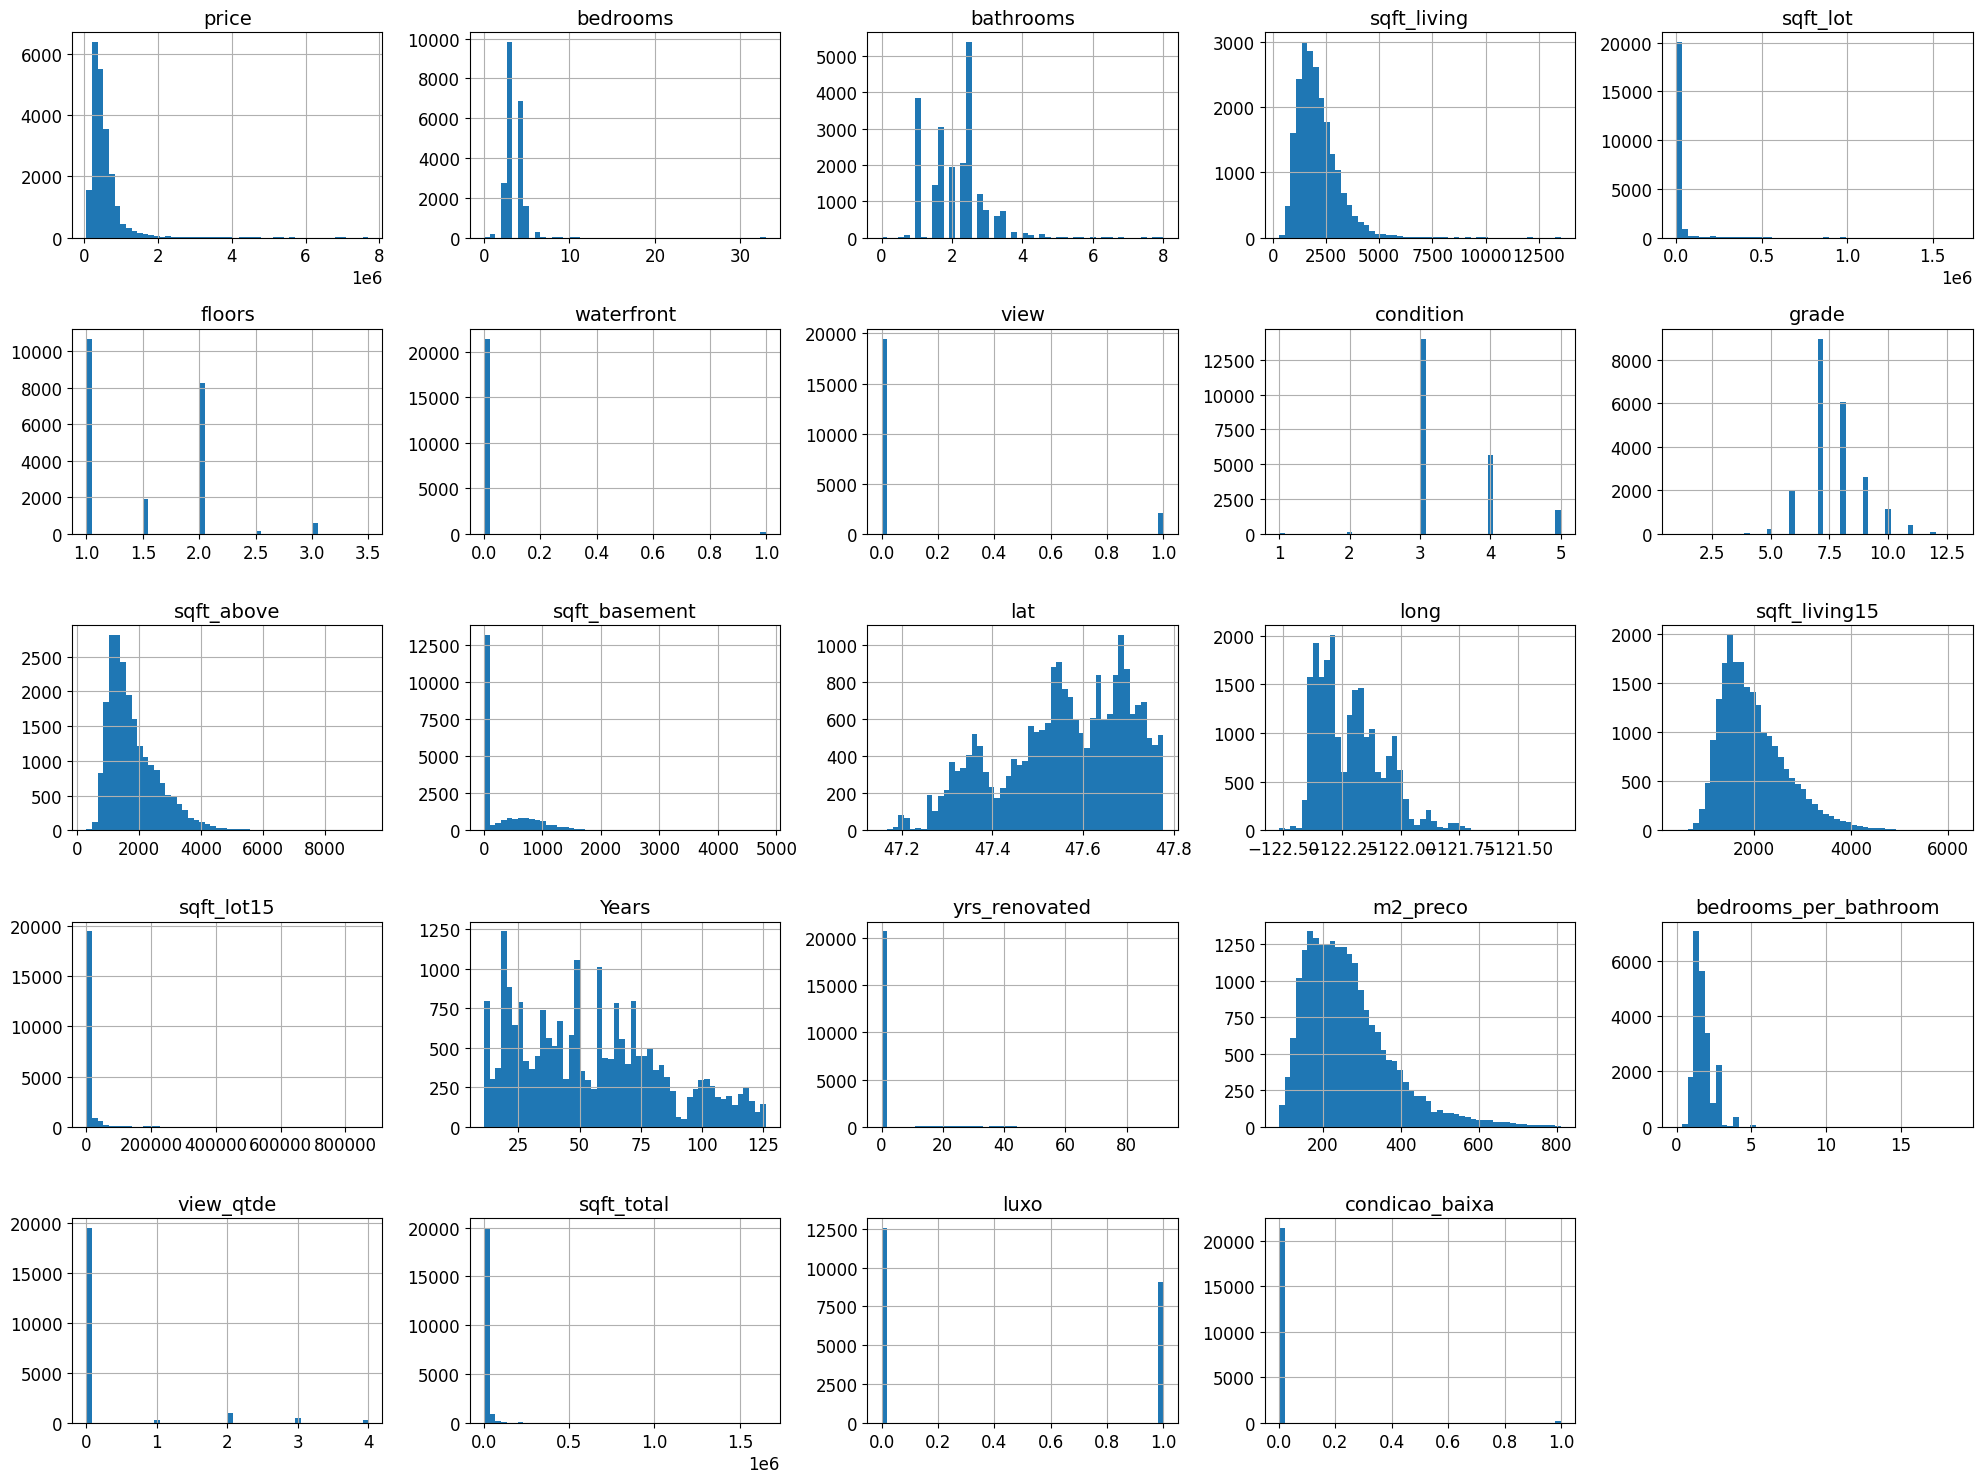

In [21]:
df.hist(bins = 50, figsize = (20,15))
save_fig("histogramas.png")
plt.show()

Salvando figura scatter_plot.png em imagens\scatter_plot.png


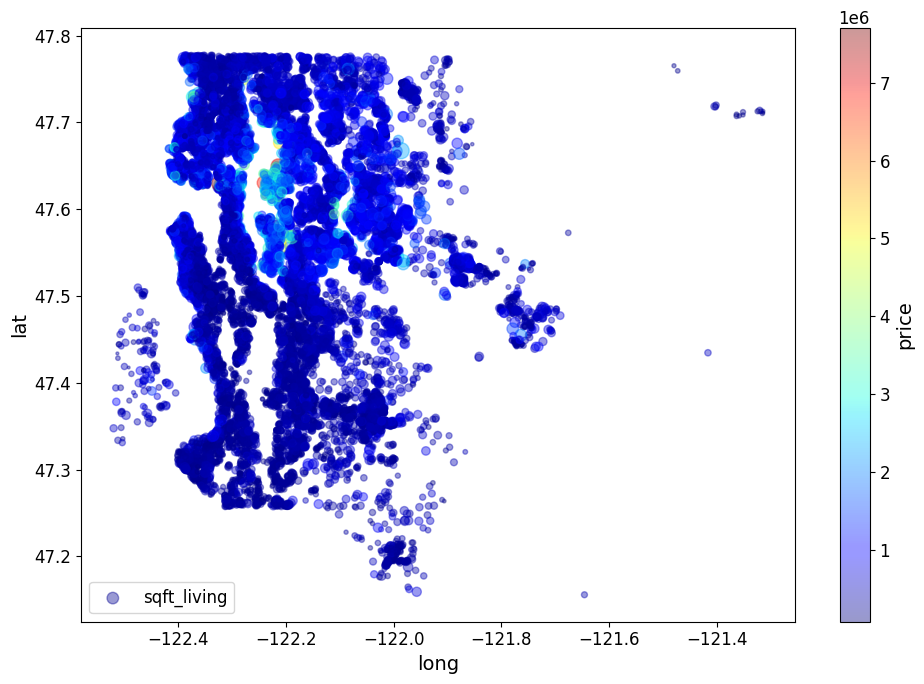

In [22]:
df.plot(kind = "scatter", x = "long", y = "lat", alpha = 0.4, s = df["sqft_living"]/100, label = "sqft_living", figsize = (10,7), c = "price", cmap = plt.get_cmap("jet"), colorbar = True)
save_fig("scatter_plot.png")
plt.show()

Salvando figura scatter_plot.png em imagens\scatter_plot.png


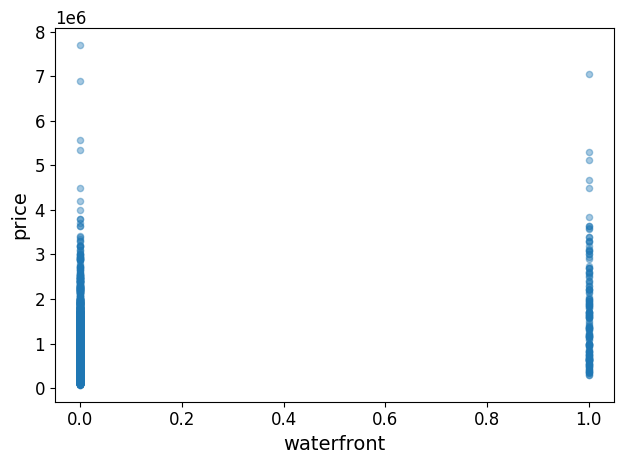

In [23]:
df.plot(kind = "scatter", x = "waterfront", y = "price", alpha = 0.4)
save_fig("scatter_plot.png")
plt.show()

In [24]:
!pip install geopandas contextily

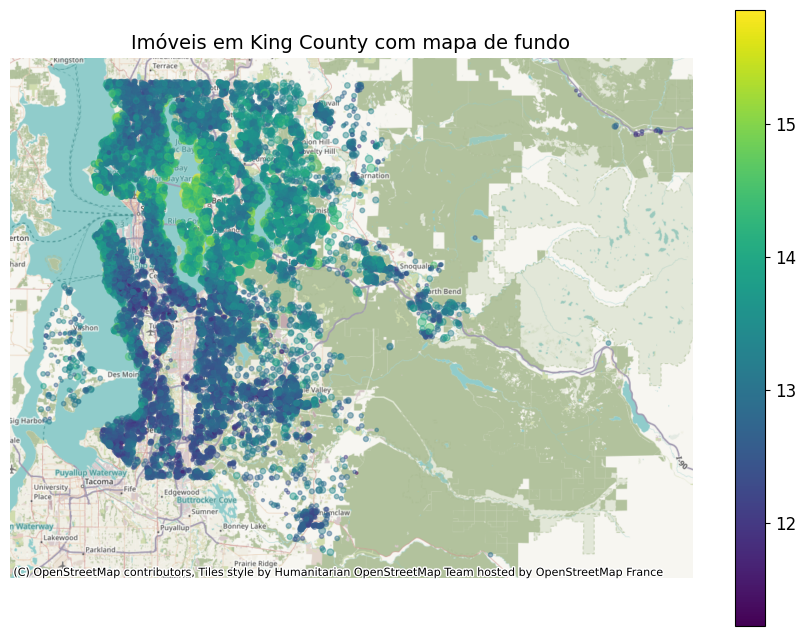

In [25]:
import pandas as pd
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np

df["log_price"] = np.log1p(df["price"])

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["long"], df["lat"]),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

ax = gdf.plot(
    column="log_price",
    markersize=gdf["sqft_living"] / 200,
    alpha=0.45,
    cmap="viridis",
    legend=True,
    figsize=(11, 8)
)

cx.add_basemap(ax)

plt.title("Imóveis em King County com mapa de fundo")
plt.axis("off")
plt.show()

## 10 Hipoteses



### H1 : Quanto maior a area construida maior é o preço do imóvel

In [26]:
corr = df.corr()
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

0.7020350546118002


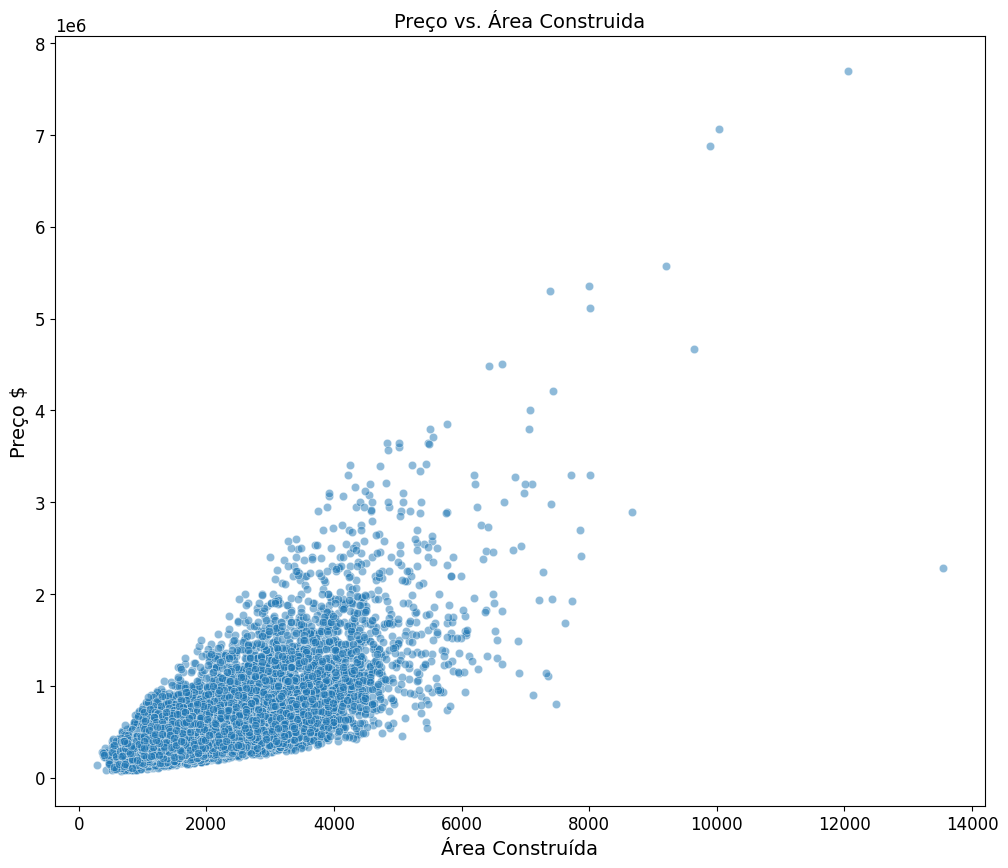

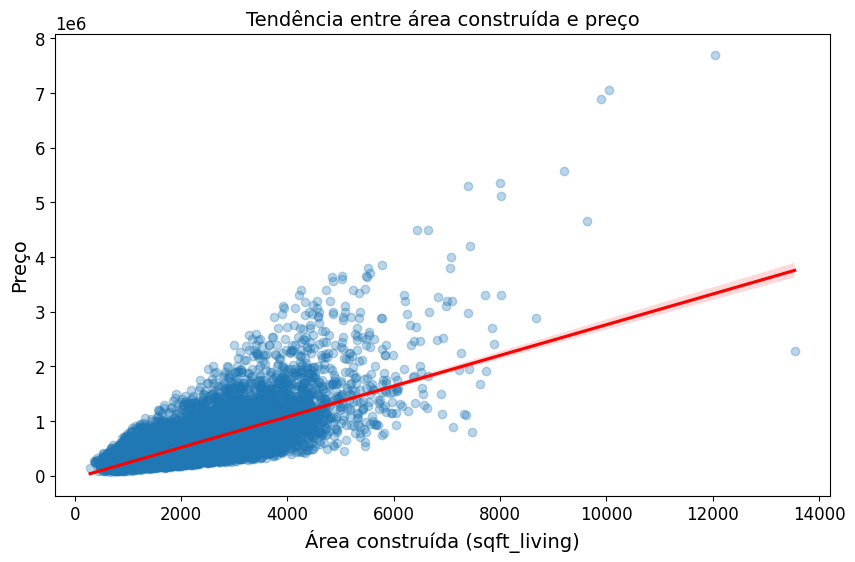

In [31]:
#Preço por metro quadrado
correlacao = df["sqft_living"].corr(df["price"], method="pearson") #pearson mede correlação linear
print(correlacao)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data = df,
    x = "sqft_living",
    y = "price",
    alpha = 0.5
)
plt.title("Preço vs. Área Construida")
plt.xlabel("Área Construída")
plt.ylabel("Preço $")
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x="sqft_living",
    y="price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Tendência entre área construída e preço")
plt.xlabel("Área construída (sqft_living)")
plt.ylabel("Preço")
plt.show()

Analisando o grafico, podemos observar que temos uma correlação positiva entre area  e preço. Mostrando que imoveis maiores tendem a ser muito caros. 

Como temos muitos outliers, talvez somente a area construida nao responde esse valor

### H2 - Qualidade x preco



    grade  count          mean     median
0       1      1  1.420000e+05   142000.0
1       3      3  2.056667e+05   262000.0
2       4     29  2.143810e+05   205000.0
3       5    242  2.485240e+05   228700.0
4       6   2038  3.019196e+05   275276.5
5       7   8981  4.025903e+05   375000.0
6       8   6068  5.428528e+05   510000.0
7       9   2615  7.735132e+05   720000.0
8      10   1134  1.071771e+06   914327.0
9      11    399  1.496842e+06  1284000.0
10     12     90  2.191222e+06  1817500.0
11     13     13  3.709615e+06  2983000.0


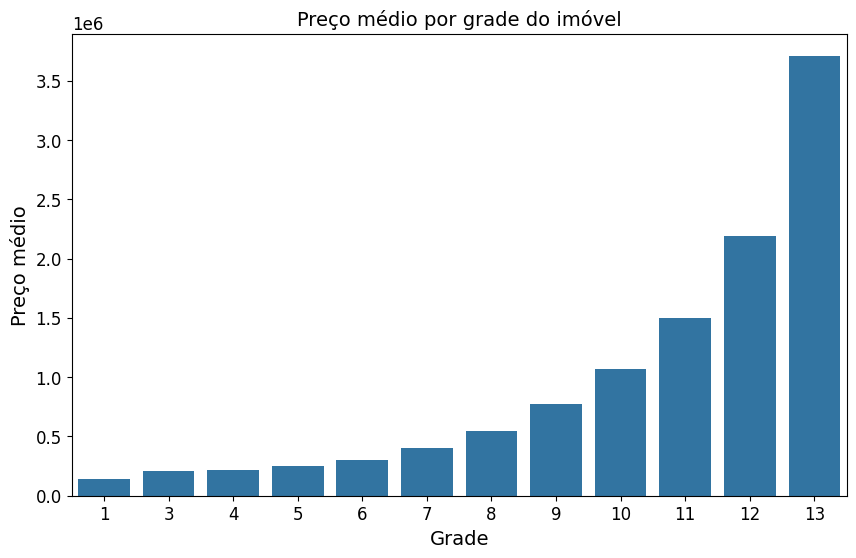

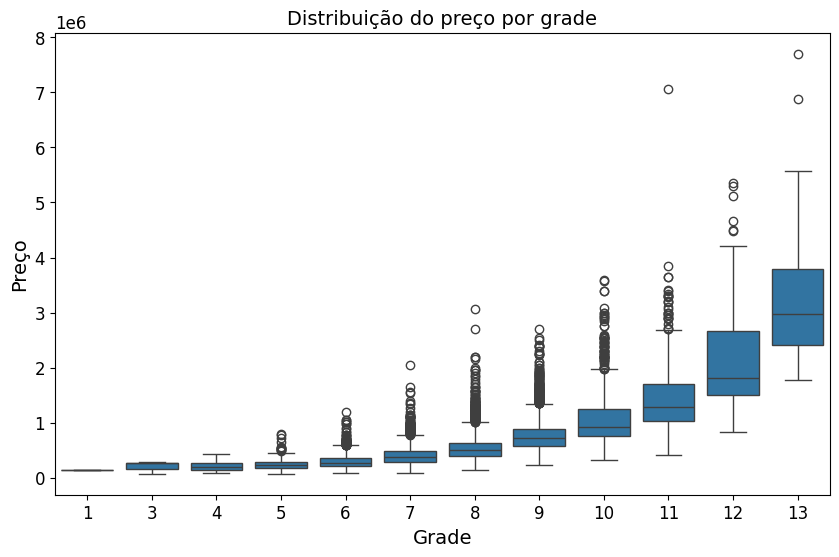

In [37]:
resumo_grade = df.groupby("grade")["price"].agg(["count", "mean", "median"]).reset_index()
print(resumo_grade)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=resumo_grade,
    x="grade",
    y="mean"
)
plt.title("Preço médio por grade do imóvel")
plt.xlabel("Grade")
plt.ylabel("Preço médio")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="grade",
    y="price"
)
plt.title("Distribuição do preço por grade")
plt.xlabel("Grade")
plt.ylabel("Preço")
plt.show()


A hipotese foi confirmada. Grade tem forte influencia no preço dos moveis. Quanto maior o grade, maior é o preço. Podemos observar isso até na mediana do boxplot

### H3 - Imoveis com vista pra agua sao mais caros

In [39]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_lot15,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total,luxo,condicao_baixa,log_price
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,5650,71,0,188.050847,3.000000,0,6830,0,0,12.309987
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,7639,75,35,209.338521,1.333333,0,9812,1,0,13.195616
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,8062,93,0,233.766234,2.000000,0,10770,0,0,12.100718
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,5000,61,0,308.163265,1.333333,0,6960,1,0,13.311331
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,7503,39,0,303.571429,1.500000,0,9760,1,0,13.142168


Preço médio com vista para água: $1,661,876.02
Preço médio sem vista para água: $531,563.60


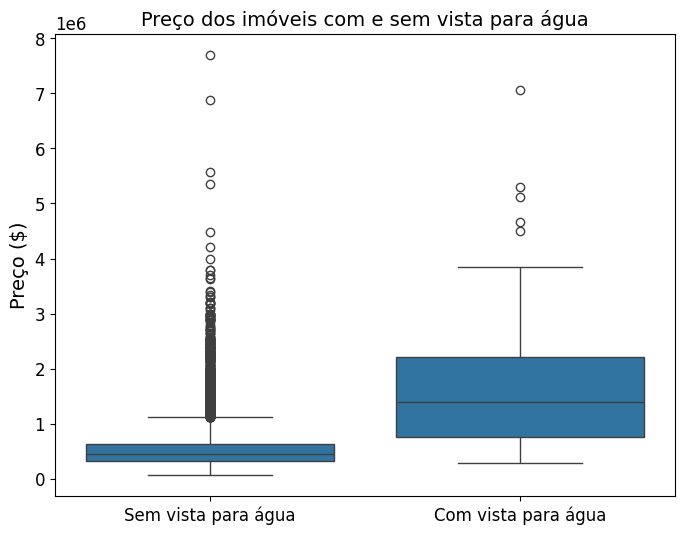

In [38]:
# Calculando médias
media_waterfront = df[df['waterfront'] == 1]['price'].mean()
media_sem_waterfront = df[df['waterfront'] == 0]['price'].mean()
print(f"Preço médio com vista para água: ${media_waterfront:,.2f}")
print(f"Preço médio sem vista para água: ${media_sem_waterfront:,.2f}")

# Boxplot para visualização
plt.figure(figsize=(8,6))
sns.boxplot(x='waterfront', y='price', data=df)
plt.xticks([0,1],["Sem vista para água","Com vista para água"])
plt.title("Preço dos imóveis com e sem vista para água")
plt.ylabel("Preço ($)")
plt.xlabel("")
plt.show()

A hipotese tambem se confirma. De acordo com o boxplot, podemos observar que nossa media do preço das casas com vista pra agua é maior.

### H4 - Imóveis com mais banheiros geralmente também possuem mais quartos

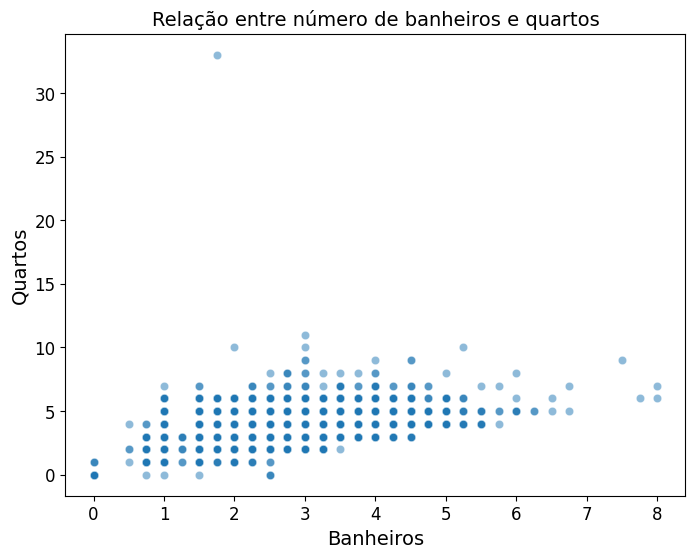

Correlação entre banheiros e quartos: 0.52


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='bathrooms', y='bedrooms', data=df, alpha=0.5)
plt.title('Relação entre número de banheiros e quartos')
plt.xlabel('Banheiros')
plt.ylabel('Quartos')
plt.show()

# Cálculo da correlação
correlacao = df['bathrooms'].corr(df['bedrooms'])
print(f'Correlação entre banheiros e quartos: {correlacao:.2f}')

Temos uma correlação mediana entre banheiro e numero de quartos. Porem , devido ao vlro, nem sempre é uma regra

### H5 - Imóveis reformados tendem a ser mais antigos do que imóveis não reformados.

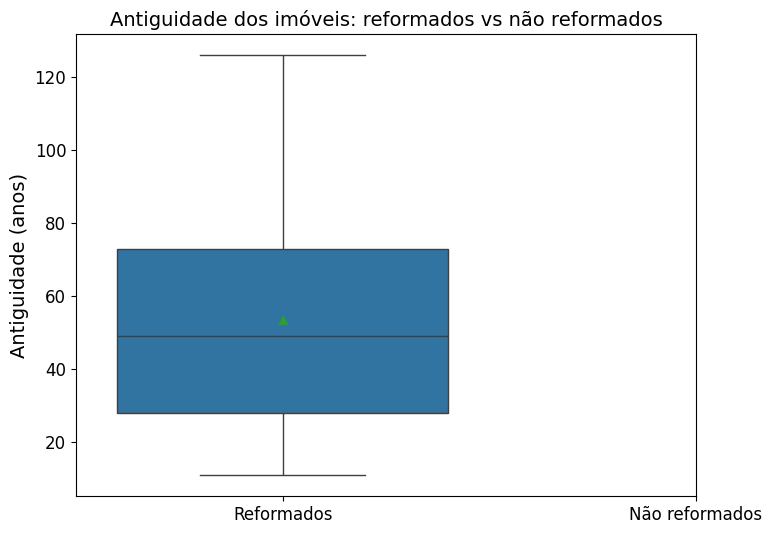

Média de antiguidade dos imóveis reformados: 86.5 anos
Média de antiguidade dos imóveis não reformados: 53.6 anos


In [41]:
antiguidade_reformados = df[df['yrs_renovated'] > 0]['Years']
antiguidade_nao_reformados = df[df['yrs_renovated'] == 0]['Years']

plt.figure(figsize=(8,6))
sns.boxplot(data=[antiguidade_reformados, antiguidade_nao_reformados], showmeans=True)
plt.xticks([0,1], ['Reformados', 'Não reformados'])
plt.ylabel('Antiguidade (anos)')
plt.title('Antiguidade dos imóveis: reformados vs não reformados')
plt.show()

media_reformados = antiguidade_reformados.mean()
media_nao_reformados = antiguidade_nao_reformados.mean()
print(f'Média de antiguidade dos imóveis reformados: {media_reformados:.1f} anos')
print(f'Média de antiguidade dos imóveis não reformados: {media_nao_reformados:.1f} anos')

Como temos uma media de idade dos imoveis. A idade casa reformada tende a ser mairo

### H6- Imóveis com waterfront tendem a ter melhor view

Média de 'view' para imóveis com waterfront: 3.77
Média de 'view' para imóveis sem waterfront: 0.21


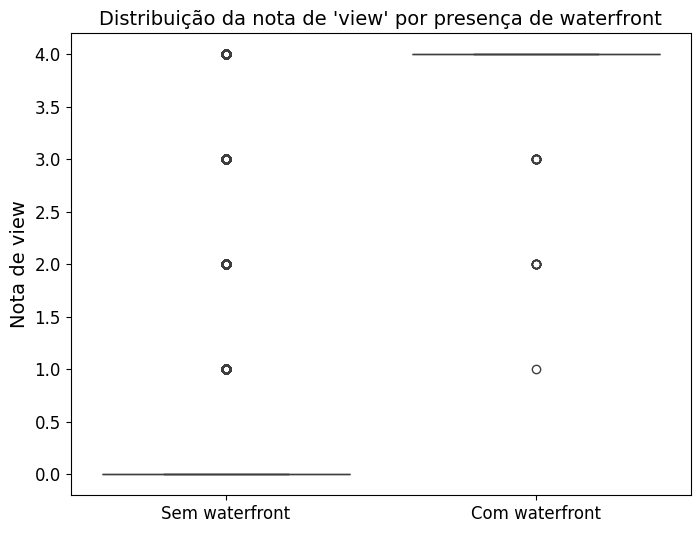

In [42]:
media_view_waterfront = df[df['waterfront'] == 1]['view_qtde'].mean()
media_view_sem_waterfront = df[df['waterfront'] == 0]['view_qtde'].mean()
print(f"Média de 'view' para imóveis com waterfront: {media_view_waterfront:.2f}")
print(f"Média de 'view' para imóveis sem waterfront: {media_view_sem_waterfront:.2f}")

# Boxplot para visualização
plt.figure(figsize=(8,6))
sns.boxplot(x='waterfront', y='view_qtde', data=df)
plt.xticks([0,1], ['Sem waterfront', 'Com waterfront'])
plt.title("Distribuição da nota de 'view' por presença de waterfront")
plt.xlabel("")
plt.ylabel("Nota de view")
plt.show()

A media de nota de view para com vista é maior. Alem disso, o bloxplot mostra que os imoveis com waterfront tem melhores valores.

### H7 - A localização influencia o padrão dos imóveis, não apenas o preço.

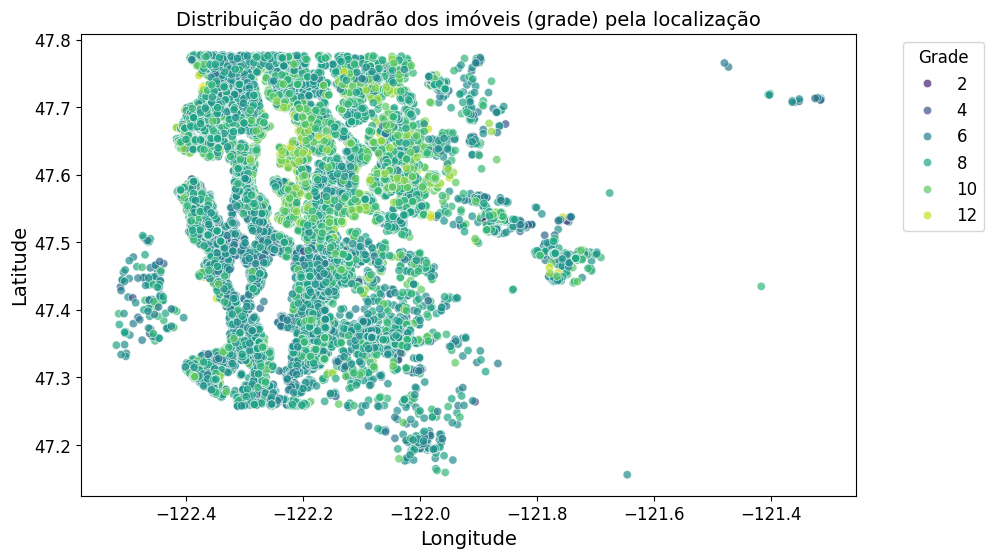

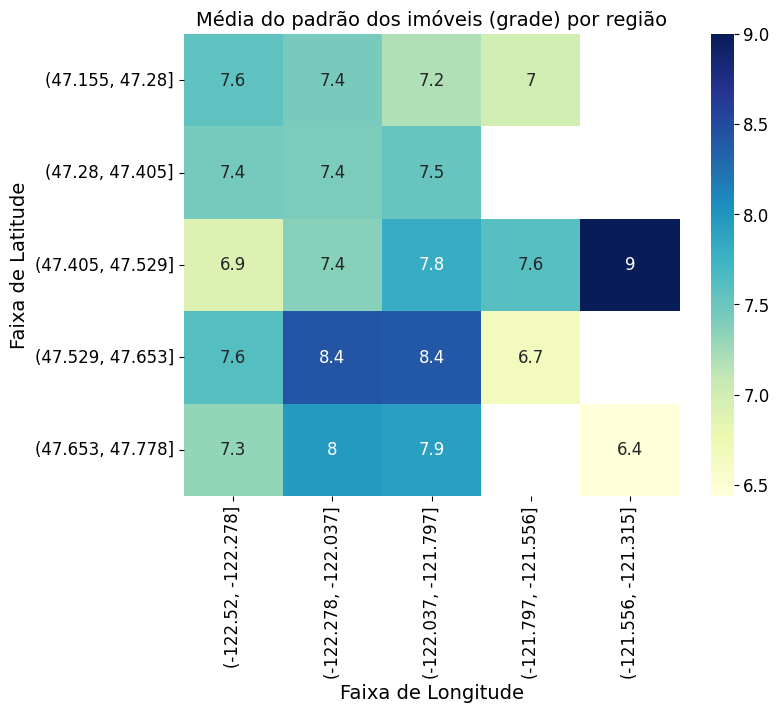

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='long', y='lat', hue='grade', data=df, palette='viridis', alpha=0.7)
plt.title('Distribuição do padrão dos imóveis (grade) pela localização')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

df['lat_bin'] = pd.cut(df['lat'], bins=5)
df['long_bin'] = pd.cut(df['long'], bins=5)
media_grade_regiao = df.groupby(['lat_bin', 'long_bin'])['grade'].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(media_grade_regiao, annot=True, cmap='YlGnBu')
plt.title('Média do padrão dos imóveis (grade) por região')
plt.xlabel('Faixa de Longitude')
plt.ylabel('Faixa de Latitude')
plt.show()

Parcialmente confirmada. De acordo com os graficos nao podemos afirmar. Temos areas que o a latitude influencia em outra nao.

### H8 - Imóveis com maior condition não necessariamente possuem maior grade.

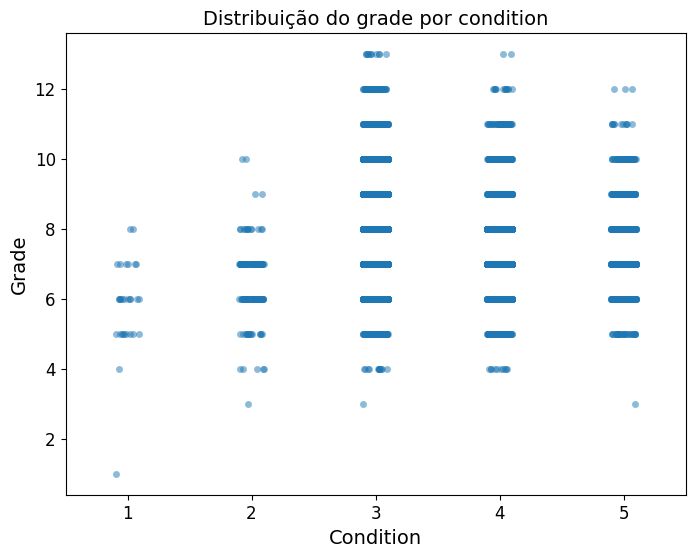

Correlação entre condition e grade: -0.14


In [45]:
plt.figure(figsize=(8,6))
sns.stripplot(x='condition', y='grade', data=df, jitter=True, alpha=0.5)
plt.title('Distribuição do grade por condition')
plt.xlabel('Condition')
plt.ylabel('Grade')
plt.show()

# Cálculo da correlação
correlacao = df['condition'].corr(df['grade'])
print(f'Correlação entre condition e grade: {correlacao:.2f}')

A hipótese foi parcialmente rejeitada. A variável condition não apresenta uma relação forte e direta com grade. Pelo gráfico, é possível perceber que imóveis com diferentes níveis de condição podem apresentar valores variados de grade

### H9 - Imóveis com mais andares (floors) tendem a ter maior área construída (sqft_living).

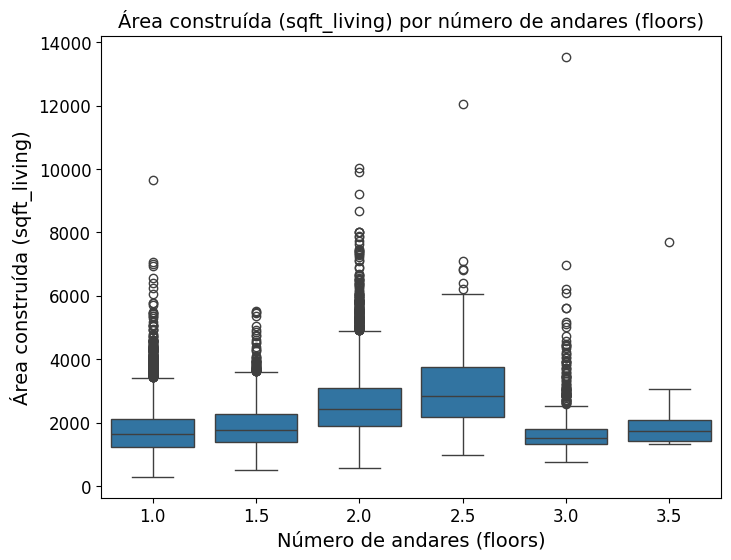

Correlação entre número de andares e área construída: 0.35


In [46]:
plt.figure(figsize=(8,6))
sns.boxplot(x='floors', y='sqft_living', data=df)
plt.title('Área construída (sqft_living) por número de andares (floors)')
plt.xlabel('Número de andares (floors)')
plt.ylabel('Área construída (sqft_living)')
plt.show()

# Cálculo da correlação
correlacao = df['floors'].corr(df['sqft_living'])
print(f'Correlação entre número de andares e área construída: {correlacao:.2f}')

A hipótese foi parcialmente confirmada. O número de andares parece ter relação com a área construída (sqft_living), mas essa relação não é totalmente linear.

### H10 - Imóveis com lotes maiores (sqft_lot) não necessariamente possuem maior área construída (sqft_living).

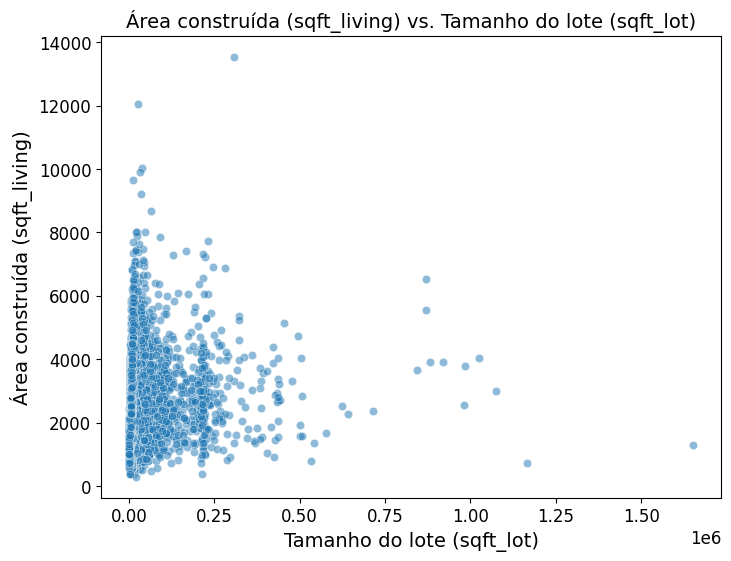

Correlação entre tamanho do lote e área construída: 0.17


In [47]:
# Análise da relação entre tamanho do lote e área construída
plt.figure(figsize=(8,6))
sns.scatterplot(x='sqft_lot', y='sqft_living', data=df, alpha=0.5)
plt.title('Área construída (sqft_living) vs. Tamanho do lote (sqft_lot)')
plt.xlabel('Tamanho do lote (sqft_lot)')
plt.ylabel('Área construída (sqft_living)')
plt.show()

# Cálculo da correlação
correlacao = df['sqft_lot'].corr(df['sqft_living'])
print(f'Correlação entre tamanho do lote e área construída: {correlacao:.2f}')

A análise do gráfico de dispersão e o valor da correlação mostram que não existe uma relação forte entre o tamanho do lote (sqft_lot) e a área construída (sqft_living).
Ou seja, lotes maiores não necessariamente resultam em casas com maior área construída, pois muitos lotes grandes podem ter casas pequenas e vice-versa. Isso confirma a hipótese.